<a href="https://colab.research.google.com/github/leonidasf300/OUU2026/blob/main/LeonSerna_OUU_project_v1_simple_feeder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple feeder to do a simple model
v1 cleaning this notebook

# Installing libraries

In [1]:
pip install pandapower[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.0/330.0 kB 12.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 26.2 MB/s eta 0:00:00
 

# Importing libraries

In [1]:
import pandapower as pp
import pandapower.shortcircuit as sc
import pandapower as pp
import pandapower.shortcircuit as sc
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt


# Creating IEC MG

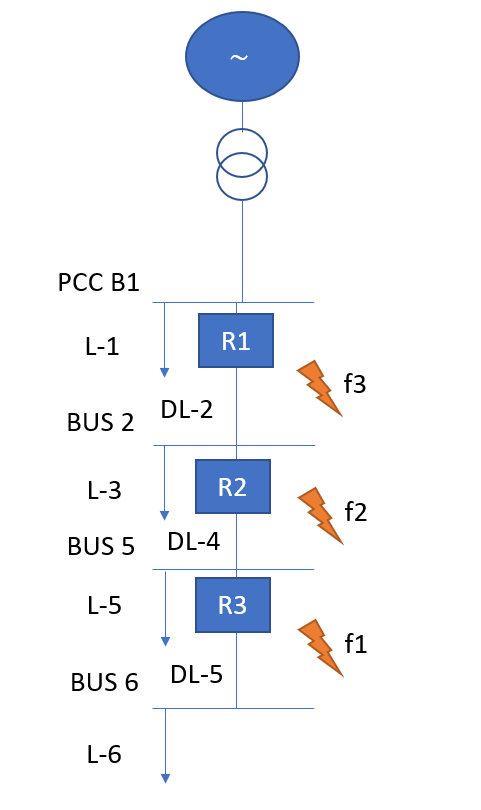

In [2]:


def create_iec_microgrid():
    # Crear red vacía
    net = pp.create_empty_network(f_hz=60.0)

    # ================= BUSES =================
    # Red de utilidad
    bus_utility = pp.create_bus(net, vn_kv=120.0, name="Utility 120kV")

    # Nivel de distribución 25 kV
    bus_pcc = pp.create_bus(net, vn_kv=25.0, name="PCC B1")
    bus2 = pp.create_bus(net, vn_kv=25.0, name="BUS 2")
    #bus3 = pp.create_bus(net, vn_kv=25.0, name="BUS 3")
    #bus4 = pp.create_bus(net, vn_kv=25.0, name="BUS 4")
    bus5 = pp.create_bus(net, vn_kv=25.0, name="BUS 5")
    bus6 = pp.create_bus(net, vn_kv=25.0, name="BUS 6")

    # Buses de Generadores (Baja Tensión)
    #bus_dg1 = pp.create_bus(net, vn_kv=2.4, name="Terminal DG1")
    #bus_dg2 = pp.create_bus(net, vn_kv=2.4, name="Terminal DG2")
    #bus_dg3 = pp.create_bus(net, vn_kv=0.575, name="Terminal DG3")
    #bus_dg4 = pp.create_bus(net, vn_kv=0.575, name="Terminal DG4")

    # ================= GRID EXTERNO =================
    # S_sc = 1000 MVA según Tabla 1
    pp.create_ext_grid(net, bus_utility, s_sc_max_mva=1000.0, rx_max=0.1, name="Utility Grid")

    # ================= TRANSFORMADORES =================
    # R1 = 0.00375 pu -> vkr = 0.375%
    # X1 = 0.1 pu (según artículo) -> vk = sqrt(0.00375^2 + 0.1^2) * 100 = 10.007%
    vkr_val = 0.00375 * 100
    vk_val = np.sqrt(0.00375**2 + 0.1**2) * 100


    # TR-1: 15 MVA, 120/25 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus_utility, lv_bus=bus_pcc, sn_mva=15.0,
                                          vn_hv_kv=120.0, vn_lv_kv=25.0, vkr_percent=vkr_val,
                                          vk_percent=vk_val, pfe_kw=30, i0_percent=0.2828, name="TR-1")
    """
    # TR-2 y TR-3: 12 MVA, 25/2.4 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus2, lv_bus=bus_dg1, sn_mva=12.0,
                                          vn_hv_kv=25.0, vn_lv_kv=2.4, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=24, i0_percent=0.2828, name="TR-2")
    pp.create_transformer_from_parameters(net, hv_bus=bus3, lv_bus=bus_dg2, sn_mva=12.0,
                                          vn_hv_kv=25.0, vn_lv_kv=2.4, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=24, i0_percent=0.2828, name="TR-3")

    # TR-4 y TR-5: 10 MVA, 25/0.575 kV
    pp.create_transformer_from_parameters(net, hv_bus=bus4, lv_bus=bus_dg3, sn_mva=10.0,
                                          vn_hv_kv=25.0, vn_lv_kv=0.575, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=20, i0_percent=0.2828, name="TR-4")
    pp.create_transformer_from_parameters(net, hv_bus=bus6, lv_bus=bus_dg4, sn_mva=10.0,
                                          vn_hv_kv=25.0, vn_lv_kv=0.575, vkr_percent=0.375,
                                          vk_percent=1.068, pfe_kw=20, i0_percent=0.2828, name="TR-5")
    """

    # ================= LÍNEAS DE DISTRIBUCIÓN =================
    # R1 = 0.413 ohm/km, L1 = 3.32e-3 H/km -> X1 = 2*pi*60*3.32e-3 = 1.251 ohm/km
    # C1 = 5.01e-9 F/km
    line_params = {
    "r_ohm_per_km": 0.413,
    "x_ohm_per_km": 1.251,
    "c_nf_per_km": 5.01,
    "r0_ohm_per_km": 0.1153, # Datos de la Tabla 5
    "x0_ohm_per_km": 0.396,  # Calculado de L0
    "c0_nf_per_km": 11.33,   # Datos de la Tabla 5
    "max_i_ka": 1.0
}

    #pp.create_line_from_parameters(net, from_bus=bus_pcc, to_bus=bus3, length_km=30.0, name="DL-1", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus_pcc, to_bus=bus2, length_km=3.0, name="DL-2", **line_params)
    #pp.create_line_from_parameters(net, from_bus=bus2, to_bus=bus4, length_km=3.0, name="DL-3", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus2, to_bus=bus5, length_km=3.0, name="DL-4", **line_params)
    pp.create_line_from_parameters(net, from_bus=bus5, to_bus=bus6, length_km=3.0, name="DL-5", **line_params)

    # Interruptores de lazo (Loop breakers) - Normalmente abiertos para operación radial
    #pp.create_switch(net, bus=bus2, element=bus4, et="b", closed=False, name="CB_LOOP 1")
    #pp.create_switch(net, bus=bus4, element=bus6, et="b", closed=False, name="CB_LOOP 2")

    # ================= GENERADORES DISTRIBUIDOS =================
    # DG1, DG2: Sincrónicos (9 MVA, xd'' = 0.177)
    #pp.create_gen(net, bus_dg1, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=2.4, xdss_pu=0.177, rdss_ohm=0.0, cos_phi=0.9, name="DG1")
    #pp.create_gen(net, bus_dg2, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=2.4, xdss_pu=0.177, rdss_ohm=0.0, cos_phi=0.9, name="DG2")

    # DG3: Inversor Eólico (6 MVA, xd'' = 0.252)
    #pp.create_gen(net, bus_dg3, p_mw=5.4, vm_pu=1.0, sn_mva=6.0, vn_kv=0.575, xdss_pu=0.252, rdss_ohm=0.0, cos_phi=0.9, name="DG3")

    # DG4: DFIG Eólico (9 MVA, Ls + Lr' = 0.34)
    #pp.create_gen(net, bus_dg4, p_mw=8.1, vm_pu=1.0, sn_mva=9.0, vn_kv=0.575, xdss_pu=0.34, rdss_ohm=0.0, cos_phi=0.9, name="DG4")

    # ================= CARGAS =================
    # Total de 22 MW y 10 MVAR dividido en 6 cargas
    p_load = 22.0 / 6.0
    q_load = 10.0 / 6.0

    pp.create_load(net, bus_pcc, p_mw=p_load, q_mvar=q_load, name="L-1")
    pp.create_load(net, bus2, p_mw=p_load, q_mvar=q_load, name="L-2")
    #pp.create_load(net, bus3, p_mw=p_load, q_mvar=q_load, name="L-3")
    #pp.create_load(net, bus4, p_mw=p_load, q_mvar=q_load, name="L-4")
    pp.create_load(net, bus5, p_mw=p_load, q_mvar=q_load, name="L-5")
    pp.create_load(net, bus6, p_mw=p_load, q_mvar=q_load, name="L-6")

    return net

# Inicializar red
net = create_iec_microgrid()

# ================= ANÁLISIS DE CORTOCIRCUITO =================
# Ejecutar cortocircuito trifásico según norma IEC 60909
# case="max" para calcular corrientes máximas de falla
sc.calc_sc(net, case="max", ip=True, ith=True, branch_results=True)

# Imprimir resultados en buses (corriente de cortocircuito subtransitoria ikss)
print("--- Resultados de Cortocircuito en Buses (ikss en kA) ---")
print(net.res_bus_sc[['ikss_ka', 'ip_ka']])

/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)
/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:1434: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  power_station_unit = trafo_df.power_station_unit.fillna(False).values.astype(bool)


--- Resultados de Cortocircuito en Buses (ikss en kA) ---
    ikss_ka      ip_ka
0  4.811252  11.880038
1  3.309837   8.765273
2  1.831511   4.161496
3  1.261011   2.723410
4  0.960669   2.023350


# Defining matrices

In [3]:

BACKUP = [[0,0,0],#R1
          [1,0,0],#R2
          [1,1,0]]#R3

CT_PS = [[800,0.5],#[[1200,1],#1
          [400,0.5],#6
          [400,0.5],#4
          [400,0.5]]#2

#             1,2,3,4
principal = [[0,0,0,1],
              [0,0,1,0],
              [0,1,0,0]]

faults = {"F1":"DL-5", "F2":"DL-4", "F3":"DL-2"}

In [4]:
headers = ["DG0", "DG1", "DG2", "DG3","DG4"]
rows = ["OM1","OM2","OM3","OM4"]

matrix = [[1,0,0,0,0],
          [1,1,1,1,1],
          [1,1,1,0,0],
          [0,1,1,1,1]]

OMS = {
    (rows[i], headers[j]): matrix[i][j]
    for i in range(len(rows))
    for j in range(len(headers))
}



In [5]:

Cindex={"STI":{"A":0.05,"B":0.04,"C":0},
        "SI":{"A":0.14,"B":0.02,"C":0},
        "VI":{"A":13.5,"B":1,"C":0}}
        # "EI":{"A":80,"B":2,"C":0},
        # "LTI":{"A":120,"B":1,"C":0},
        # "UI":{"A":315.2,"B":2.5,"C":0},
        # "IEEE-LTI":{"A":0.086,"B":0.05,"C":0.185},
        # "IEEE-LTVI":{"A":28.55,"B":2,"C":0.712},
        # "IEEE-LTEI":{"A":64.07,"B":2,"C":0.25},
        # "IEEE-MI":{"A":0.0515,"B":0.02,"C":0.114},
        # "IEEE-VI":{"A":19.61,"B":2,"C":0.491},
        # "IEEE-EI":{"A":28.2,"B":2,"C":0.1217},
        # "IEEE-STI":{"A":0.16758,"B":0.02,"C":0.11858},
        # "IEEE-STEI":{"A":1.281,"B":2,"C":0.005}}
C=["STI", "SI", "VI"]#,"EI","LTI","IEEE-LTI","IEEE-LTVI","IEEE-LTEI","IEEE-MI","IEEE-VI","IEEE-EI","IEEE-STI","IEEE-STEI"]


# Function calculate_sc_percentage

In [6]:
def calculate_sc_percentage(net, nombre_linea, pasos=10):
    # 1. Identificar la línea original
    line_idx = net.line[net.line.name == nombre_linea].index[0]
    bus_inicial = net.line.at[line_idx, "from_bus"]
    bus_final = net.line.at[line_idx, "to_bus"]
    L_total = net.line.at[line_idx, "length_km"]
    params = {
        "r_ohm_per_km": net.line.at[line_idx, "r_ohm_per_km"],
        "x_ohm_per_km": net.line.at[line_idx, "x_ohm_per_km"],
        "c_nf_per_km": net.line.at[line_idx, "c_nf_per_km"],
        "max_i_ka": net.line.at[line_idx, "max_i_ka"]
    }

    # 2. Desactivar la línea original
    net.line.at[line_idx, "in_service"] = False

    # Identificar las lineas de los relés y guardarlas directamente
    relay_idx = [
        net.line[net.line.name == "DL-2"].index[0],
        net.line[net.line.name == "DL-4"].index[0],
        net.line[net.line.name == "DL-5"].index[0]
    ]

    pos_virtual_line = relay_idx.index(line_idx)
    resultados = []

    # 3. Iterar cada 10% (o el paso definido)
    for i in range(1, pasos):
        porcentaje = i / pasos
        distancia_falla = L_total * porcentaje

        # Crear bus temporal de falla
        f_bus = pp.create_bus(net, vn_kv=net.bus.at[bus_inicial, "vn_kv"], name=f"Falla_{int(porcentaje*100)}%")

        # Crear los dos tramos de línea que conectan al punto de falla
        l1 = pp.create_line_from_parameters(net, bus_inicial, f_bus, distancia_falla, name="tramo_A", **params)
        l2 = pp.create_line_from_parameters(net, f_bus, bus_final, L_total - distancia_falla, name="tramo_B", **params)
        relay_idx[pos_virtual_line] = l1


        # 4. Ejecutar SC con branch_results=True para ver qué ven los relés en los extremos
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sc.calc_sc(net, bus=f_bus, branch_results=True)

        # Guardar datos: I_total en falla, I que ve Relé inicial (l1), I que ve Relé final (l2)
        # resultados.append({
        #     "Porcentaje": f"{int(porcentaje*100)}%",
        #     "I_falla_total": net.res_bus_sc.ikss_ka.at[f_bus],
        #     "I_Relé_Front": net.res_line_sc.ikss_ka.at[l1],
        #     "I_Relé_Back": net.res_line_sc.ikss_ka.at[l2]
        # })
        #print(net.res_line_sc)
        resultados.append({
            "Porcentaje": porcentaje*100,
            "R0": net.res_line_sc.ikss_ka.at[relay_idx[0]]*1000,
            "R1": net.res_line_sc.ikss_ka.at[relay_idx[1]]*1000,
            "R2": net.res_line_sc.ikss_ka.at[relay_idx[2]]*1000
        })


        # Limpiar para no acumular líneas en el modelo
        pp.drop_lines(net, [l1, l2])
        pp.drop_buses(net, [f_bus])

    # Restaurar línea original
    net.line.at[line_idx, "in_service"] = True
    #return pd.DataFrame(resultados)
    return pd.DataFrame(resultados)

dftest=calculate_sc_percentage(net, nombre_linea="DL-4", pasos=10)
dftest

,Porcentaje,R0,R1,R2
0,10.0,1752.466600,1752.466600,0.0
1,20.0,1679.900233,1679.900233,0.0
2,30.0,1613.053966,1613.053966,0.0
3,40.0,1551.282537,1551.282537,0.0
4,50.0,1494.033467,1494.033467,0.0
5,60.0,1440.831087,1440.831087,0.0
6,70.0,1391.263733,1391.263733,0.0
7,80.0,1344.973400,1344.973400,0.0
8,90.0,1301.647328,1301.647328,0.0


# Beta equation

Base Time Factor Calculation ($\beta_{ficd}$)This equation determines the base time factor ($\beta$) for inverse overcurrent curves (IEC/IEEE), unifying the physical power system currents with the internal relay settings.

$$\beta_{ficd} = \frac{A_c}{\left(\frac{ICC_{ifd}}{Ipickup_i \times CTR_i}\right)^{B_c}-1}$$

* Variable Definitions:$ICC_{ifd}$: Short-circuit current on the primary side $[A]$ (obtained from simulations).
* $Ipickup_i$: Pickup current or tap of relay $i$ on the secondary side $[A]$.
* $CTR_i$: Current Transformer Ratio (CTR) associated with relay $i$ $(\frac{I_{nominal\_primary}}{I_{nominal\_secondary}})$.
* $A_c, B_c$: Mathematical constants defining the shape of the selected inverse curve $c$ (e.g., Very Inverse, Extremely Inverse).

*Consistency Note:* The product $(Ipickup_i \times CTR_i)$ translates the relay setting into primary amperes so it can be directly divided by the fault current.If the term inside the parentheses (PSM) is $\le 1$, it means the fault current is lower than the pickup setting; the relay will not operate, and the mathematical result will be negative (invalid).

In [25]:
Findex=[f"F{i+1}" for i in range(3)]
Rindex=[f"R{i+1}" for i in range(3)]

BETA=dict()
B=dict()

dsteps = 10
steps = [i / dsteps for i in range(1, dsteps)]

for fault in range(len(Findex)):
  ICC_fid = calculate_sc_percentage(net, nombre_linea=faults[Findex[fault]], pasos=dsteps)
  for index, ICCdata in ICC_fid.iterrows():
    for relay in range(len(Rindex)):
      for curve in range(len(C)):
        ICC = ICCdata[f"R{relay}"]
        dist_fault = ICCdata["Porcentaje"]
        #print(f"f:{fault},i:{relay},c:{curve},d:{dist_fault:.2f}")

        PSMif=(ICC)/(CT_PS[relay][0]*CT_PS[relay][1])
        #BETA[Findex[fault],Rindex[relay],C[curve]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)
        BETA[Findex[fault],Rindex[relay],C[curve],steps[index]]=(Cindex[C[curve]]["A"])/((PSMif**Cindex[C[curve]]["B"])-1)


for main in range(len(Rindex)):
  for backup in range(len(Rindex)):
    B[Rindex[main],Rindex[backup]] = BACKUP[main][backup]


In [26]:
# Convert the BETA dictionary to a list of dictionaries for DataFrame creation
beta_data = []
for key, value in BETA.items():
    falla, rele, curva, distancia = key
    beta_data.append({
        'Falla': falla,
        'Rele': rele,
        'Curva': curva,
        'Distancia': distancia,
        'Beta': value
    })

# Create the DataFrame
beta_df = pd.DataFrame(beta_data)

# Display the first few rows of the DataFrame
display(beta_df.head())


,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.1,1.093802
1,F1,R1,SI,0.1,6.194507
2,F1,R1,VI,0.1,6.562772
3,F1,R2,STI,0.1,0.665681
4,F1,R2,SI,0.1,3.796544


In [27]:
beta_df[beta_df["Rele"]=="R4"]

,Falla,Rele,Curva,Distancia,Beta


In [28]:
beta_df[beta_df["Beta"]>0]

,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.1,1.093802
1,F1,R1,SI,0.1,6.194507
2,F1,R1,VI,0.1,6.562772
3,F1,R2,STI,0.1,0.665681
4,F1,R2,SI,0.1,3.796544
...,...,...,...,...,...
226,F3,R1,SI,0.8,4.262561
227,F3,R1,VI,0.8,3.348232
234,F3,R1,STI,0.9,0.772690
235,F3,R1,SI,0.9,4.395969


In [29]:
beta_df[beta_df["Falla"]=="F2"]

,Falla,Rele,Curva,Distancia,Beta
81,F2,R1,STI,0.1,0.821376
82,F2,R1,SI,0.1,4.668671
83,F2,R1,VI,0.1,3.992705
84,F2,R2,STI,0.1,0.551276
85,F2,R2,SI,0.1,3.155626
...,...,...,...,...,...
157,F2,R2,SI,0.9,3.667620
158,F2,R2,VI,0.9,2.450875
159,F2,R3,STI,0.9,-0.050000
160,F2,R3,SI,0.9,-0.140000


#Plot Beta


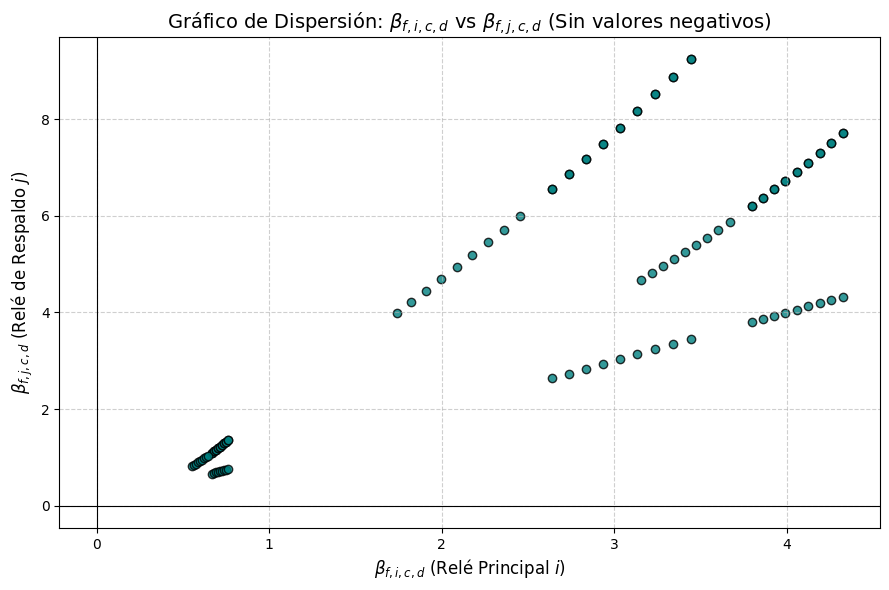

In [30]:
# 1. Filtrar los valores negativos directamente en el DataFrame
# Conservamos solo las filas donde Beta es mayor o igual a 0
df_filtrado = beta_df[beta_df['Beta'] >= 0]

# 2. Definir la matriz BACKUP y los nombres de los relés
BACKUP = [
    [0, 0, 0], # R1
    [1, 0, 0], # R2
    [1, 1, 0]  # R3
]
reles = ['R1', 'R2', 'R3']

# 3. Encontrar los pares (i, j) válidos iterando sobre la matriz
pares_ij = []
for idx_i, fila in enumerate(BACKUP):
    for idx_j, valor in enumerate(fila):
        if valor == 1:
            pares_ij.append((reles[idx_i], reles[idx_j]))

# 4. Extraer las coordenadas X e Y
puntos_x = []
puntos_y = []

# Agrupamos por las condiciones fijas usando el DataFrame ya filtrado
grupos = df_filtrado.groupby(['Falla','Distancia', 'Curva'])

for (f, c, d), grupo in grupos:
    # print(f, c, d)
    # print(grupo)
    for i, j in pares_ij:
        # Extraemos el valor para el relé principal (i)
        beta_i = grupo[grupo['Rele'] == i]['Beta'].values
        # Extraemos el valor para el relé de respaldo (j)
        beta_j = grupo[grupo['Rele'] == j]['Beta'].values

        # Solo agregamos el punto si AMBOS relés tienen datos válidos (positivos)
        if len(beta_i) > 0 and len(beta_j) > 0:
            puntos_x.append(beta_i[0])
            puntos_y.append(beta_j[0])

# 5. Configurar y mostrar la gráfica
plt.figure(figsize=(9, 6))
plt.scatter(puntos_x, puntos_y, color='teal', alpha=0.8, edgecolor='black')

# Formato matemático para los títulos
plt.title(r'Gráfico de Dispersión: $\beta_{f,i,c,d}$ vs $\beta_{f,j,c,d}$ (Sin valores negativos)', fontsize=14)
plt.xlabel(r'$\beta_{f,i,c,d}$ (Relé Principal $i$)', fontsize=12)
plt.ylabel(r'$\beta_{f,j,c,d}$ (Relé de Respaldo $j$)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.8) # Línea en Y=0
plt.axvline(0, color='black', linewidth=0.8) # Línea en X=0
plt.tight_layout()
plt.show()

# Beta plot 2

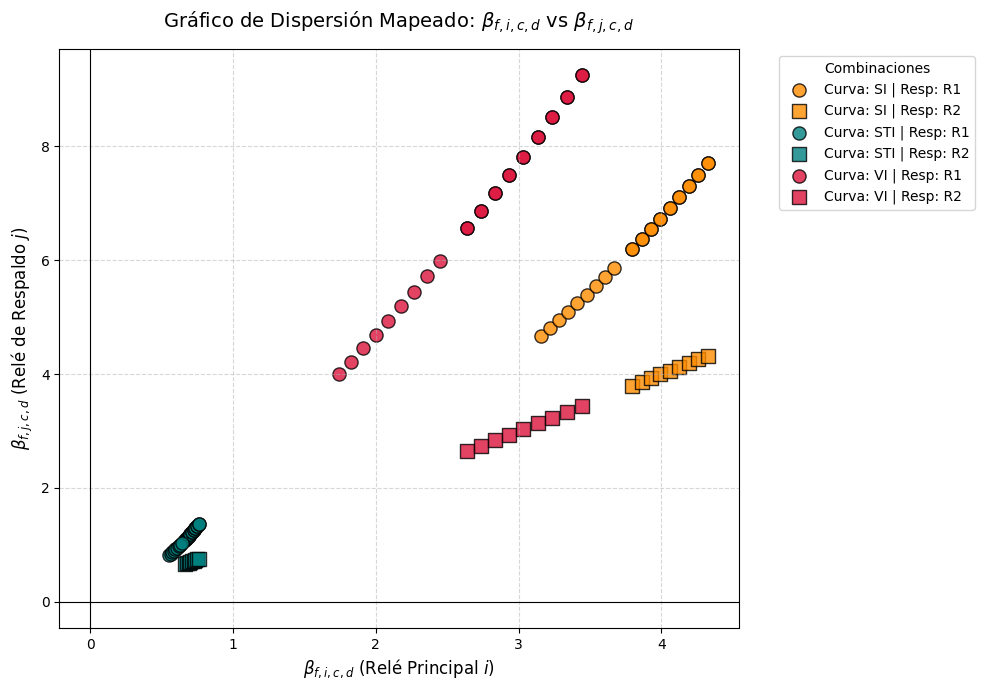

In [31]:
import matplotlib.pyplot as plt
from collections import defaultdict

# 1. Filtrar los valores negativos directamente en el DataFrame
df_filtrado = beta_df[beta_df['Beta'] >= 0]

# 2. Definir la matriz BACKUP y los nombres de los relés
BACKUP = [
    [0, 0, 0], # R1
    [1, 0, 0], # R2
    [1, 1, 0]  # R3
]
reles = ['R1', 'R2', 'R3']

# 3. Encontrar los pares (i, j) válidos iterando sobre la matriz
pares_ij = []
for idx_i, fila in enumerate(BACKUP):
    for idx_j, valor in enumerate(fila):
        if valor == 1:
            pares_ij.append((reles[idx_i], reles[idx_j]))

# --- NUEVO: ASIGNACIÓN DINÁMICA DE COLORES Y JUEGO DE MARKERS ---
# Extraemos las curvas únicas del DataFrame para asignarles un color
curvas_unicas = df_filtrado['Curva'].unique()
paleta_colores = ['teal', 'darkorange', 'crimson', 'purple', 'forestgreen']
mapa_colores = {curva: paleta_colores[idx % len(paleta_colores)] for idx, curva in enumerate(curvas_unicas)}

# Extraemos los relés de respaldo únicos de nuestros pares_ij para asignarles un marcador
respaldos_unicos = sorted(list(set([j for i, j in pares_ij])))
estilos_markers = ['o', 's', '^', 'D', 'v', 'p'] # Círculo, Cuadrado, Triángulo, Diamante...
mapa_markers = {rele_j: estilos_markers[idx % len(estilos_markers)] for idx, rele_j in enumerate(respaldos_unicos)}

# 4. Extraer las coordenadas organizadas por combinación (Curva, Respaldo)
# Usamos un diccionario que creará listas automáticamente para cada combinación
puntos_combinados = defaultdict(lambda: {'x': [], 'y': []})

# Agrupamos (Nota el ajuste en el orden del desempaquetado: f, d, c)
grupos = df_filtrado.groupby(['Falla', 'Distancia', 'Curva'])

for (f, d, c), grupo in grupos:
    for i, j in pares_ij:
        # Extraemos el valor para el relé principal (i)
        beta_i = grupo[grupo['Rele'] == i]['Beta'].values
        # Extraemos el valor para el relé de respaldo (j)
        beta_j = grupo[grupo['Rele'] == j]['Beta'].values

        # Solo agregamos si ambos relés tienen datos válidos
        if len(beta_i) > 0 and len(beta_j) > 0:
            # Clasificamos el punto según su Curva (c) y su Relé de Respaldo (j)
            puntos_combinados[(c, j)]['x'].append(beta_i[0])
            puntos_combinados[(c, j)]['y'].append(beta_j[0])

# 5. Configurar y mostrar la gráfica
plt.figure(figsize=(10, 7))

# Graficamos cada combinación por separado para que Matplotlib genere la leyenda correctamente
for (c, j), coordenadas in puntos_combinados.items():
    if coordenadas['x']: # Nos aseguramos de que la combinación tenga puntos
        plt.scatter(
            coordenadas['x'],
            coordenadas['y'],
            color=mapa_colores[c],     # El color depende de la Curva
            marker=mapa_markers[j],    # El marcador depende del Relé J
            s=90,                      # Tamaño de los puntos
            alpha=0.8,
            edgecolor='black',
            label=f'Curva: {c} | Resp: {j}' # Etiqueta automática para la leyenda
        )

# Formato matemático para los títulos
plt.title(r'Gráfico de Dispersión Mapeado: $\beta_{f,i,c,d}$ vs $\beta_{f,j,c,d}$', fontsize=14, pad=15)
plt.xlabel(r'$\beta_{f,i,c,d}$ (Relé Principal $i$)', fontsize=12)
plt.ylabel(r'$\beta_{f,j,c,d}$ (Relé de Respaldo $j$)', fontsize=12)

# Añadir la leyenda explicativa
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title="Combinaciones")

plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [32]:
pares_ij

[('R2', 'R1'), ('R3', 'R1'), ('R3', 'R2')]

In [33]:
mydist=df_filtrado["Distancia"].unique()
type(mydist[0])

numpy.float64

In [34]:
#df_filtrado[(df_filtrado["Falla"]=="F1") & (df_filtrado["Curva"]=="STI") & (df_filtrado["Rele"]=="R1")]

df_filtrado[(df_filtrado["Falla"]=="F1") & (df_filtrado["Distancia"]==mydist[0])]

,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.1,1.093802
1,F1,R1,SI,0.1,6.194507
2,F1,R1,VI,0.1,6.562772
3,F1,R2,STI,0.1,0.665681
4,F1,R2,SI,0.1,3.796544
5,F1,R2,VI,0.1,2.639753
6,F1,R3,STI,0.1,0.665681
7,F1,R3,SI,0.1,3.796544
8,F1,R3,VI,0.1,2.639753


In [35]:
df_filtrado[(df_filtrado["Falla"]=="F1")]

,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.1,1.093802
1,F1,R1,SI,0.1,6.194507
2,F1,R1,VI,0.1,6.562772
3,F1,R2,STI,0.1,0.665681
4,F1,R2,SI,0.1,3.796544
...,...,...,...,...,...
76,F1,R2,SI,0.9,4.323384
77,F1,R2,VI,0.9,3.443310
78,F1,R3,STI,0.9,0.759732
79,F1,R3,SI,0.9,4.323384


# Beta plot 3


In [38]:
df_filtrado[(df_filtrado['Curva']=="STI")&(df_filtrado['Falla']=='F1')].sort_values(by=['Rele','Distancia'])

,Falla,Rele,Curva,Distancia,Beta
0,F1,R1,STI,0.1,1.093802
9,F1,R1,STI,0.2,1.124491
18,F1,R1,STI,0.3,1.155955
27,F1,R1,STI,0.4,1.188237
36,F1,R1,STI,0.5,1.221383
45,F1,R1,STI,0.6,1.255439
54,F1,R1,STI,0.7,1.290456
63,F1,R1,STI,0.8,1.326487
72,F1,R1,STI,0.9,1.363587
3,F1,R2,STI,0.1,0.665681


Text(0, 0.5, '$\\beta_{i=R2,c=STI}$')

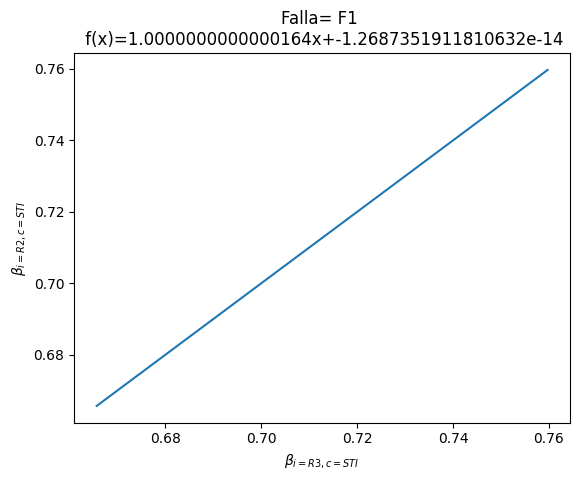

In [58]:
Ry='R2'
Cy='STI'
Rx='R3'
Cx='STI'
F='F1'


list_x=df_filtrado[(df_filtrado['Rele']==Rx)&(df_filtrado['Curva']==Cx)&(df_filtrado['Falla']==F)].sort_values(by=['Rele','Distancia'])['Beta'].to_list()
list_y=df_filtrado[(df_filtrado['Rele']==Ry)&(df_filtrado['Curva']==Cy)&(df_filtrado['Falla']==F)].sort_values(by=['Rele','Distancia'])['Beta'].to_list()
plt.plot(list_x,list_y)
m,b = np.polyfit(list_x, list_y, 1)
plt.title(f"Falla= {F} \n f(x)={m}x+{b}")
plt.xlabel(fr"$\beta_{{i={Rx},c={Cx}}}$")
plt.ylabel(fr"$\beta_{{i={Ry},c={Cy}}}$")

# Beta plot i=R3 y j=R2


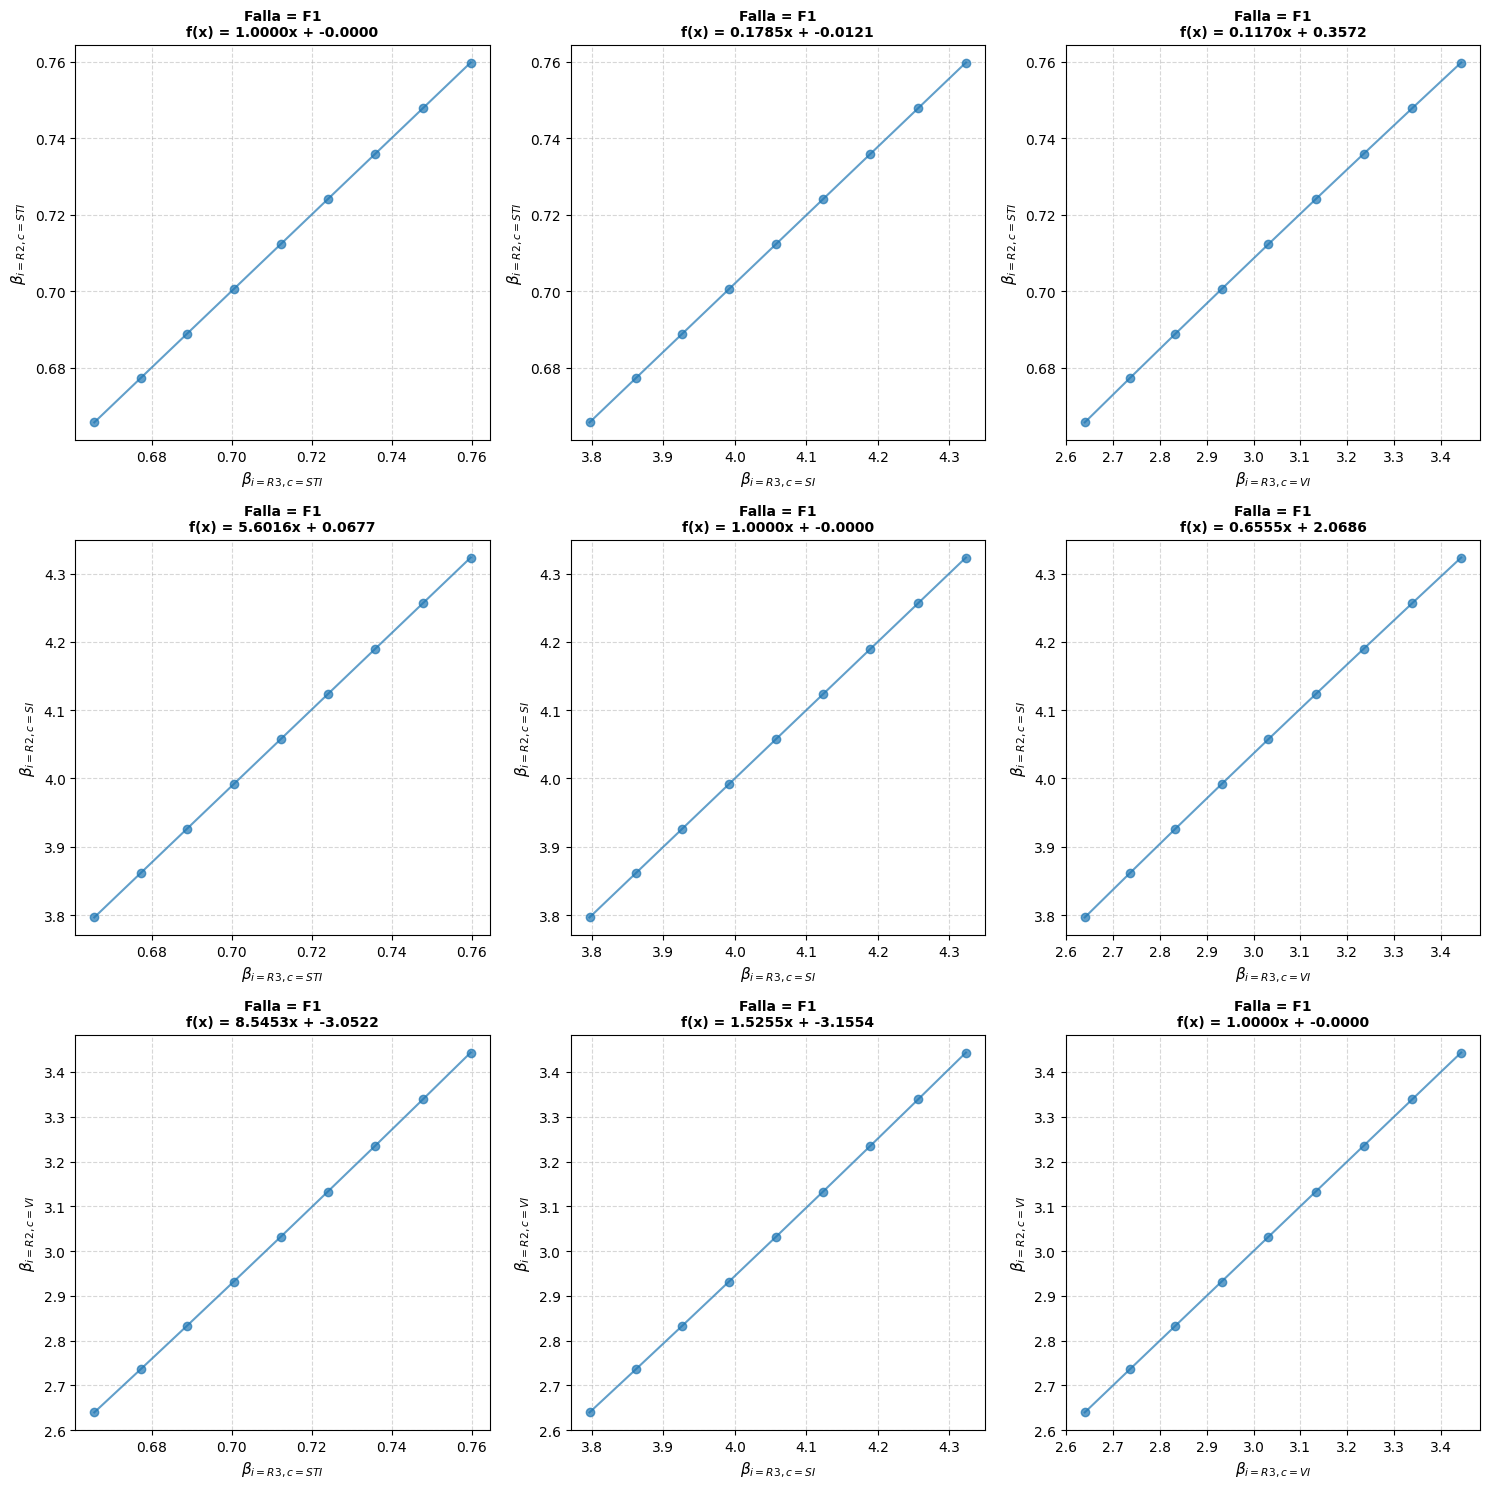

In [63]:
# 1. Filtrar los valores negativos en el DataFrame
df_filtrado = beta_df[beta_df['Beta'] >= 0]

# 2. Definir los parámetros fijos (Ajusta la pareja de Relés y la Falla que desees evaluar)
Rx = 'R3'
Ry = 'R2'
F = 'F1'

# Definir la lista de las 3 curvas habilitadas.
# Nota: En el fragmento de datos provisto se observan 'STI' y 'SI'[cite: 1].
# He añadido 'VI' (Very Inverse) como ejemplo para completar las 3 curvas de tu sistema real.
curvas = ['STI', 'SI', 'VI']
# Si prefieres que se lea 100% automático de lo que haya en tu columna, descomenta la siguiente línea:
# curvas = list(df_filtrado['Curva'].unique())

# 3. Inicializar la matriz de subplots de 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# 4. Iterar sobre filas (Cy) y columnas (Cx) para construir la matriz
for row_idx, Cy in enumerate(curvas):
    for col_idx, Cx in enumerate(curvas):
        # Seleccionar el recuadro (eje) correspondiente en la matriz
        ax = axes[row_idx, col_idx]

        # Filtrar el set de datos para el eje X (Relé Rx, Curva Cx, Falla F)
        df_x = df_filtrado[(df_filtrado['Rele'] == Rx) &
                           (df_filtrado['Curva'] == Cx) &
                           (df_filtrado['Falla'] == F)]

        # Filtrar el set de datos para el eje Y (Relé Ry, Curva Cy, Falla F)
        df_y = df_filtrado[(df_filtrado['Rele'] == Ry) &
                           (df_filtrado['Curva'] == Cy) &
                           (df_filtrado['Falla'] == F)]

        # CRUCIAL: Alinear perfectamente los puntos usando un merge por 'Distancia'
        df_coordenadas = pd.merge(df_x, df_y, on='Distancia', suffixes=('_x', '_y')).sort_values(by='Distancia')

        list_x = df_coordenadas['Beta_x'].to_list()
        list_y = df_coordenadas['Beta_y'].to_list()

        # 5. Verificar que existan datos suficientes (mínimo 2 puntos para trazar una recta)
        if len(list_x) >= 2:
            # Graficar la línea continua con marcadores en los puntos reales
            ax.plot(list_x, list_y, marker='o', linestyle='-', color='tab:blue', alpha=0.7, label='Datos')

            # Calcular la regresión lineal (Ecuación interpolada)
            m, b = np.polyfit(list_x, list_y, 1)

            # Configurar el título incluyendo la ecuación (limitada a 4 decimales para mayor limpieza visual)
            ax.set_title(f"Falla = {F}\nf(x) = {m:.4f}x + {b:.4f}", fontsize=10, fontweight='bold')
        else:
            # En caso de que una combinación no tenga registros en el DataFrame (ej. la curva 'VI' en el set de prueba)
            ax.text(0.5, 0.5, 'Sin datos coincidentes', ha='center', va='center', color='gray', fontsize=10)
            ax.set_title(f"Falla = {F}\n[Datos Insuficientes]", fontsize=10, color='gray')

        # 6. Formato estético y etiquetas matemáticas con LaTeX de cada subplot
        ax.set_xlabel(fr"$\beta_{{i={Rx}, c={Cx}}}$", fontsize=11)
        ax.set_ylabel(fr"$\beta_{{i={Ry}, c={Cy}}}$", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)

# Ajustar automáticamente los espacios entre las gráficas para evitar que se traslapen los textos
plt.tight_layout()
plt.show()

# Beta plot i=R3 y j=R1


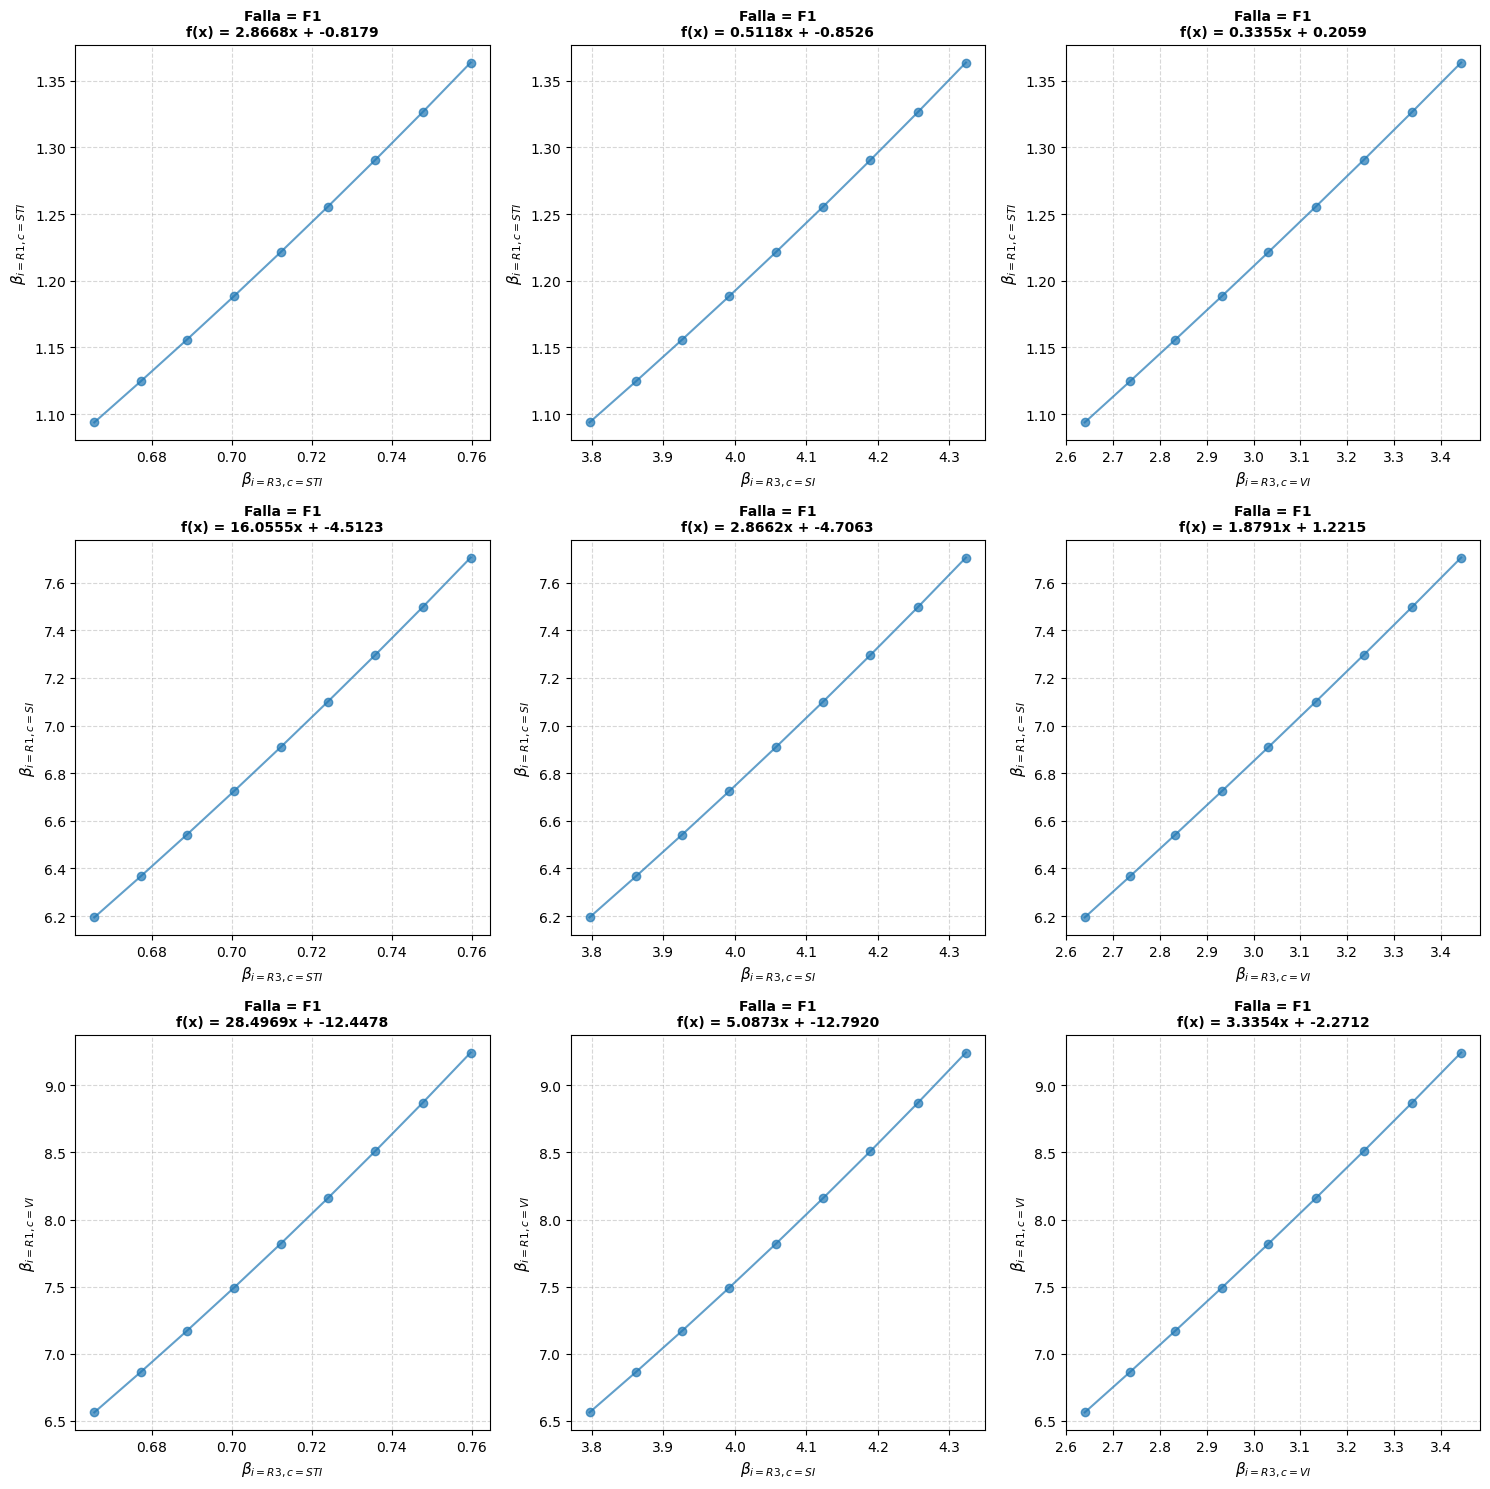

In [64]:
# 1. Filtrar los valores negativos en el DataFrame
df_filtrado = beta_df[beta_df['Beta'] >= 0]

# 2. Definir los parámetros fijos (Ajusta la pareja de Relés y la Falla que desees evaluar)
Rx = 'R3'
Ry = 'R1'
F = 'F1'

# Definir la lista de las 3 curvas habilitadas.
# Nota: En el fragmento de datos provisto se observan 'STI' y 'SI'[cite: 1].
# He añadido 'VI' (Very Inverse) como ejemplo para completar las 3 curvas de tu sistema real.
curvas = ['STI', 'SI', 'VI']
# Si prefieres que se lea 100% automático de lo que haya en tu columna, descomenta la siguiente línea:
# curvas = list(df_filtrado['Curva'].unique())

# 3. Inicializar la matriz de subplots de 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# 4. Iterar sobre filas (Cy) y columnas (Cx) para construir la matriz
for row_idx, Cy in enumerate(curvas):
    for col_idx, Cx in enumerate(curvas):
        # Seleccionar el recuadro (eje) correspondiente en la matriz
        ax = axes[row_idx, col_idx]

        # Filtrar el set de datos para el eje X (Relé Rx, Curva Cx, Falla F)
        df_x = df_filtrado[(df_filtrado['Rele'] == Rx) &
                           (df_filtrado['Curva'] == Cx) &
                           (df_filtrado['Falla'] == F)]

        # Filtrar el set de datos para el eje Y (Relé Ry, Curva Cy, Falla F)
        df_y = df_filtrado[(df_filtrado['Rele'] == Ry) &
                           (df_filtrado['Curva'] == Cy) &
                           (df_filtrado['Falla'] == F)]

        # CRUCIAL: Alinear perfectamente los puntos usando un merge por 'Distancia'
        df_coordenadas = pd.merge(df_x, df_y, on='Distancia', suffixes=('_x', '_y')).sort_values(by='Distancia')

        list_x = df_coordenadas['Beta_x'].to_list()
        list_y = df_coordenadas['Beta_y'].to_list()

        # 5. Verificar que existan datos suficientes (mínimo 2 puntos para trazar una recta)
        if len(list_x) >= 2:
            # Graficar la línea continua con marcadores en los puntos reales
            ax.plot(list_x, list_y, marker='o', linestyle='-', color='tab:blue', alpha=0.7, label='Datos')

            # Calcular la regresión lineal (Ecuación interpolada)
            m, b = np.polyfit(list_x, list_y, 1)

            # Configurar el título incluyendo la ecuación (limitada a 4 decimales para mayor limpieza visual)
            ax.set_title(f"Falla = {F}\nf(x) = {m:.4f}x + {b:.4f}", fontsize=10, fontweight='bold')
        else:
            # En caso de que una combinación no tenga registros en el DataFrame (ej. la curva 'VI' en el set de prueba)
            ax.text(0.5, 0.5, 'Sin datos coincidentes', ha='center', va='center', color='gray', fontsize=10)
            ax.set_title(f"Falla = {F}\n[Datos Insuficientes]", fontsize=10, color='gray')

        # 6. Formato estético y etiquetas matemáticas con LaTeX de cada subplot
        ax.set_xlabel(fr"$\beta_{{i={Rx}, c={Cx}}}$", fontsize=11)
        ax.set_ylabel(fr"$\beta_{{i={Ry}, c={Cy}}}$", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)

# Ajustar automáticamente los espacios entre las gráficas para evitar que se traslapen los textos
plt.tight_layout()
plt.show()

# Beta plot i=R2 y j=R1

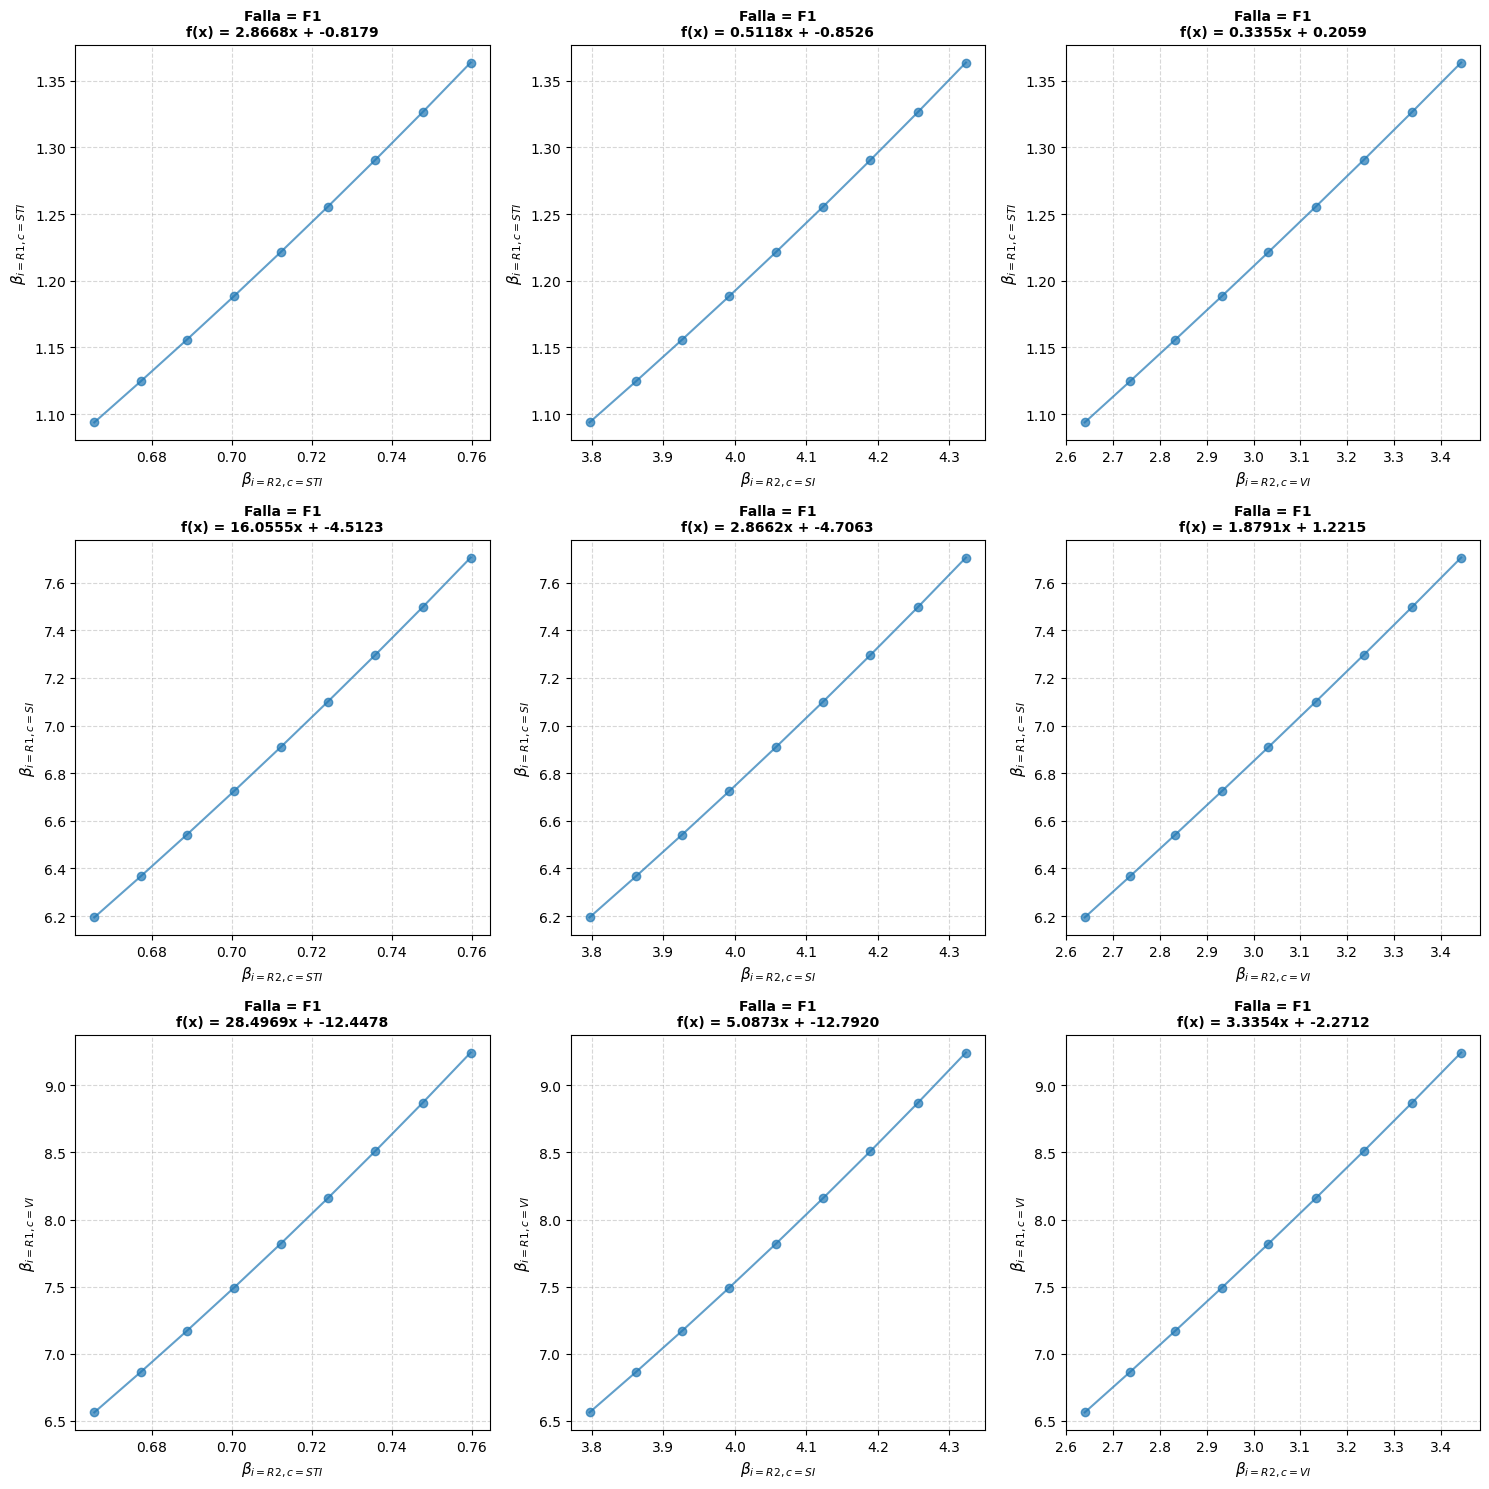

In [65]:
# 1. Filtrar los valores negativos en el DataFrame
df_filtrado = beta_df[beta_df['Beta'] >= 0]

# 2. Definir los parámetros fijos (Ajusta la pareja de Relés y la Falla que desees evaluar)
Rx = 'R2'
Ry = 'R1'
F = 'F1'

# Definir la lista de las 3 curvas habilitadas.
# Nota: En el fragmento de datos provisto se observan 'STI' y 'SI'[cite: 1].
# He añadido 'VI' (Very Inverse) como ejemplo para completar las 3 curvas de tu sistema real.
curvas = ['STI', 'SI', 'VI']
# Si prefieres que se lea 100% automático de lo que haya en tu columna, descomenta la siguiente línea:
# curvas = list(df_filtrado['Curva'].unique())

# 3. Inicializar la matriz de subplots de 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# 4. Iterar sobre filas (Cy) y columnas (Cx) para construir la matriz
for row_idx, Cy in enumerate(curvas):
    for col_idx, Cx in enumerate(curvas):
        # Seleccionar el recuadro (eje) correspondiente en la matriz
        ax = axes[row_idx, col_idx]

        # Filtrar el set de datos para el eje X (Relé Rx, Curva Cx, Falla F)
        df_x = df_filtrado[(df_filtrado['Rele'] == Rx) &
                           (df_filtrado['Curva'] == Cx) &
                           (df_filtrado['Falla'] == F)]

        # Filtrar el set de datos para el eje Y (Relé Ry, Curva Cy, Falla F)
        df_y = df_filtrado[(df_filtrado['Rele'] == Ry) &
                           (df_filtrado['Curva'] == Cy) &
                           (df_filtrado['Falla'] == F)]

        # CRUCIAL: Alinear perfectamente los puntos usando un merge por 'Distancia'
        df_coordenadas = pd.merge(df_x, df_y, on='Distancia', suffixes=('_x', '_y')).sort_values(by='Distancia')

        list_x = df_coordenadas['Beta_x'].to_list()
        list_y = df_coordenadas['Beta_y'].to_list()

        # 5. Verificar que existan datos suficientes (mínimo 2 puntos para trazar una recta)
        if len(list_x) >= 2:
            # Graficar la línea continua con marcadores en los puntos reales
            ax.plot(list_x, list_y, marker='o', linestyle='-', color='tab:blue', alpha=0.7, label='Datos')

            # Calcular la regresión lineal (Ecuación interpolada)
            m, b = np.polyfit(list_x, list_y, 1)

            # Configurar el título incluyendo la ecuación (limitada a 4 decimales para mayor limpieza visual)
            ax.set_title(f"Falla = {F}\nf(x) = {m:.4f}x + {b:.4f}", fontsize=10, fontweight='bold')
        else:
            # En caso de que una combinación no tenga registros en el DataFrame (ej. la curva 'VI' en el set de prueba)
            ax.text(0.5, 0.5, 'Sin datos coincidentes', ha='center', va='center', color='gray', fontsize=10)
            ax.set_title(f"Falla = {F}\n[Datos Insuficientes]", fontsize=10, color='gray')

        # 6. Formato estético y etiquetas matemáticas con LaTeX de cada subplot
        ax.set_xlabel(fr"$\beta_{{i={Rx}, c={Cx}}}$", fontsize=11)
        ax.set_ylabel(fr"$\beta_{{i={Ry}, c={Cy}}}$", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)

# Ajustar automáticamente los espacios entre las gráficas para evitar que se traslapen los textos
plt.tight_layout()
plt.show()